In [1]:
from FS_PRGDS_Interval_Tensor import FS_PRGDS_tensor
from tqdm.auto import tqdm
import torch
%load_ext Cython
%load_ext autoreload
%autoreload 2

# The easiest situation: deep=1

In [2]:
V=12
T=300
sys = torch.zeros(T, V)
high_value = 50
low_value = 0
############# Stage 1 #############
sys[0:100, 0:4] = torch.poisson(high_value*torch.ones(100,4))        # 1st community
############# Stage 2 #############
sys[100:200, 4:8] = torch.poisson(high_value*torch.ones(100,4))        # 2st community
############# Stage 3 #############
sys[200:300, 8:12] = torch.poisson(high_value*torch.ones(100,4))        # 3st community

burnin = 60
maxiter = 20
params = {
'tau': 1.,
'alpha0': 10.,
'epsilon_the': 0.1,
'epsilon_lam': 1.,
'stationary': True,
'data' : sys,
}
params['data'] = sys
params['K'] = 12
params['S'] = 60

fs_prgds = FS_PRGDS_tensor(**params)
esti_steady = []
transition_steady = []
# design phi we could get correct estimation of intensity under K=3
fs_prgds.phi[0][:,:] = 0.
fs_prgds.phi[0][0:4,0:4] = 0.25
fs_prgds.phi[0][4:8,4:8] = 0.25
fs_prgds.phi[0][8:12,8:12] = 0.25
fs_prgds.pi  = torch.tile(fs_prgds.phi[0], (params['S'],1,1))
fs_prgds.pit = torch.tile(fs_prgds.phi[0], (T,1,1))
for iter in tqdm(range(burnin+maxiter)):
    fs_prgds.sample_n()
    fs_prgds.sample_h()
    fs_prgds.sample_the()
    fs_prgds.sample_lam()
    fs_prgds.sample_delt()
    fs_prgds.sample_g()
    fs_prgds.sample_gam()
    fs_prgds.sample_beta()
    fs_prgds.sample_phi()
    fs_prgds.sample_pi()
    fs_prgds.sample_eta()
    fs_prgds.sample_A()
    fs_prgds.sample_dpgm()

    if iter > burnin:
        esti_temp = fs_prgds.phi[0] @ torch.diag(fs_prgds.lam) @ (fs_prgds.the).T @ torch.diag(fs_prgds.delt)
        esti_steady.append(esti_temp.clone())
        transition_steady.append(fs_prgds.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 0.8633 seconds
sample_h took 1.7126 seconds
sample_the took 0.0016 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0003 seconds
sample_g took 0.0008 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0001 seconds
sample_phi took 0.0022 seconds
sample_pi took 0.0698 seconds
sample_eta took 0.0013 seconds
Sum over self.A:  tensor(6128)
sample_A took 3.1718 seconds
sample_dpgm took 0.1514 seconds
sample_n took 0.5239 seconds
sample_h took 1.6804 seconds
sample_the took 0.0014 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0002 seconds
sample_g took 0.0008 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0001 seconds
sample_phi took 0.0020 seconds
sample_pi took 0.0697 seconds
sample_eta took 0.0012 seconds
Sum over self.A:  tensor(5921)
sample_A took 2.7579 seconds
sample_dpgm took 0.1594 seconds
sample_n took 0.5190 seconds
sample_h took 1.4804 seconds
sample_the took 0.0014 seconds
sample_lam took 0.0002 seconds
sample_delt took 0.0002 

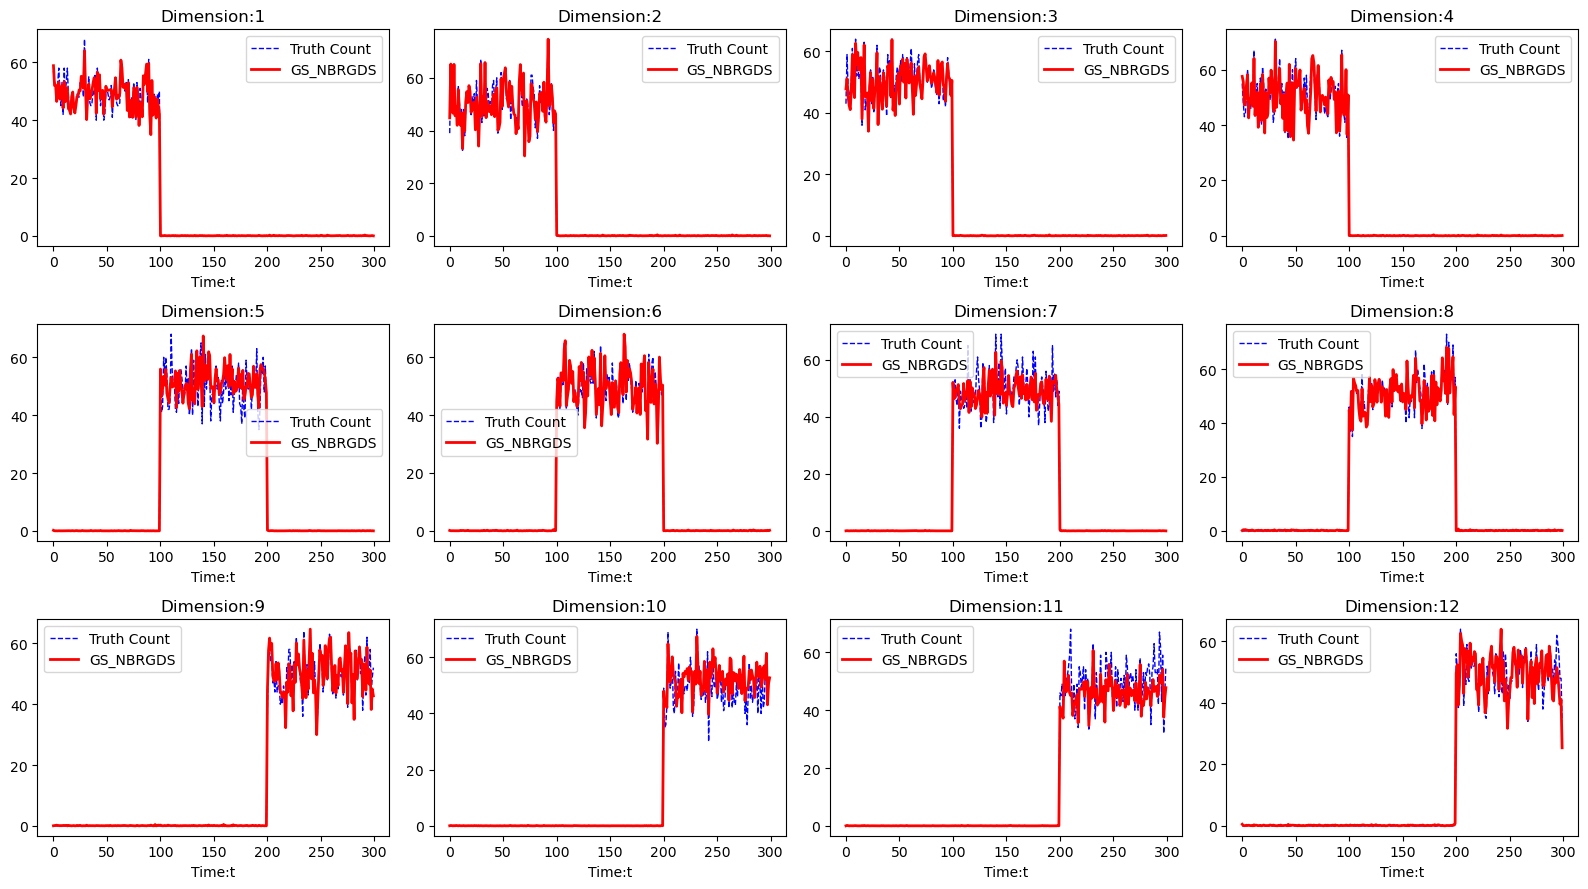

In [3]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
esti_steady = torch.stack(esti_steady)
esti_mean = torch.mean(esti_steady, axis = 0)
fig, axs = plt.subplots(3,4, figsize=(16,9))
for i, ax in enumerate(axs.flatten()):
    ax.plot(sys[:,i], color = 'blue', linewidth = 1, linestyle = '--', label = 'Truth Count')
    ax.plot(esti_mean[i], color = 'red', linewidth = 2, label = 'GS_NBRGDS')
    ax.set_title(f'Dimension:{i+1}')
    ax.set_xlabel('Time:t')
    ax.legend()
plt.tight_layout()
plt.show()

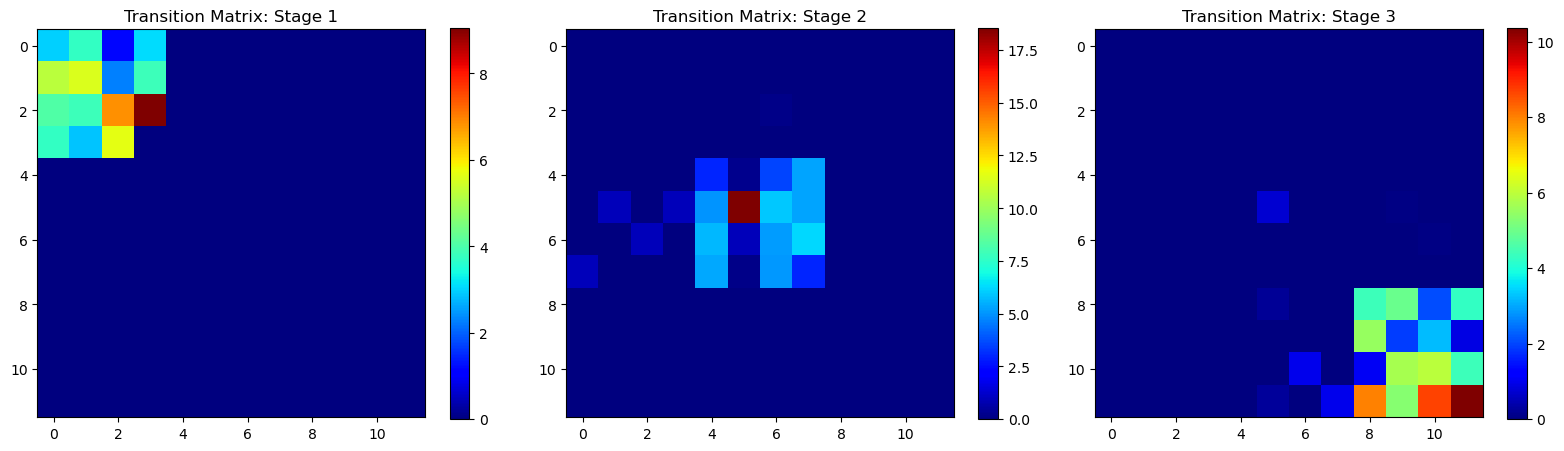

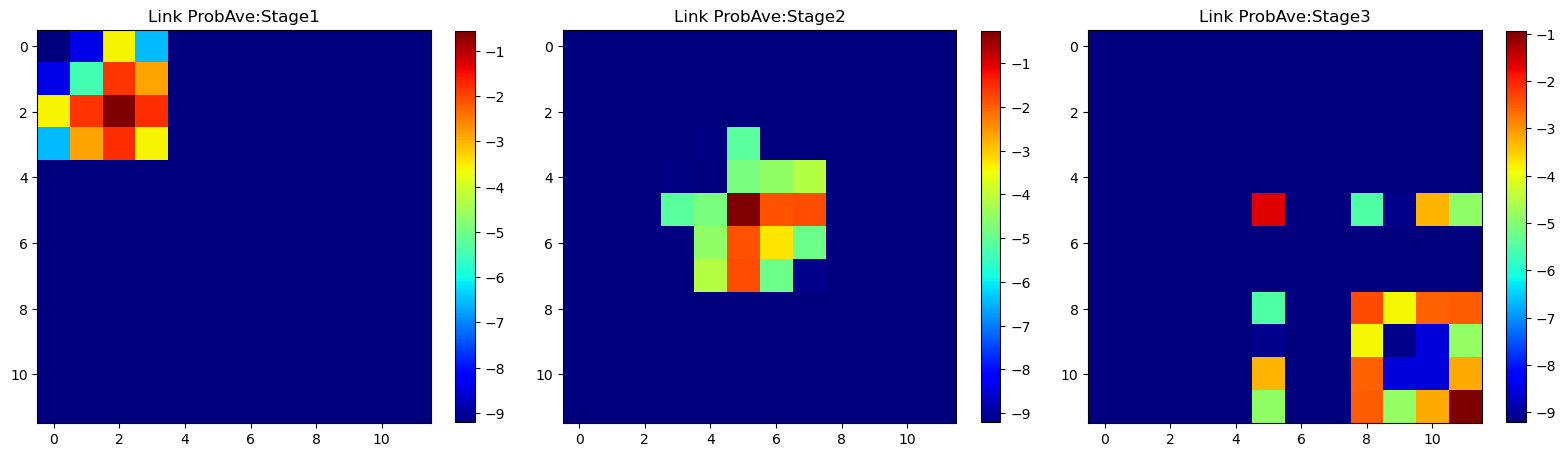

In [4]:
%matplotlib inline
transition_steady = torch.stack(transition_steady) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(1, 3, figsize=(16, 9))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        transition_sum = np.sum(np.array(transition_mean)[4:20], axis = 0)
    else:
        transition_sum = np.sum(np.array(transition_mean)[i*20: i*20+20], axis=0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Stage {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.45)
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (16,9))
for i in range(3):
    if i == 0:
        ProbAve = torch.mean(fs_prgds.ProbAve[4:20], axis = 0)
    else:
        ProbAve = torch.mean(fs_prgds.ProbAve[i*20:i*20+20], axis = 0) 
    im = axs[i].imshow(torch.log(ProbAve + ProbAve.T + 0.0001), cmap='jet')
    axs[i].set_title(f'Link ProbAve:Stage{i+1}')
    cbar = plt.colorbar(im, ax = axs[i], shrink=0.45)
plt.tight_layout()
plt.show()

# Deep=2, mode 1 = 60, mode 2 = 60, time = 300, interval = 3, community=20*20

In [5]:
# generate sysnthetic data
T = 300
S = 3
high_value = 10
sys = torch.zeros(T,60,60)
sys[0:100, 0:20, 0:20] = torch.poisson(high_value*torch.ones(100,20,20))
sys[100:200, 20:40, 20:40] = torch.poisson(high_value*torch.ones(100,20,20))
sys[200:300, 40:60, 40:60] = torch.poisson(high_value*torch.ones(100,20,20))

In [6]:
# run model
burnin = 60
maxiter = 20
params = {
'tau': 1.,
'alpha0': 10.,
'epsilon_the': 0.1,
'epsilon_lam': 1.,
'stationary': True,
'data' : sys,
'K' : 30, # latent components
'S' : 60 # sub-intervals
}

fs_prgds = FS_PRGDS_tensor(**params)
esti_steady = []
transition_steady = []
# phi should be a list
fs_prgds.phi[0][:,:] = 0.
fs_prgds.phi[0][0:20,0:10] = 1/20
fs_prgds.phi[0][20:40,10:20] = 1/20
fs_prgds.phi[0][40:60,20:30] = 1/20
fs_prgds.phi[1][:,:] = 0.
fs_prgds.phi[1][0:20,0:10] = 1/20
fs_prgds.phi[1][20:40,10:20] = 1/20
fs_prgds.phi[1][40:60,20:30] = 1/20

initial_pi = torch.zeros(30,30)
initial_pi[0:10, 0:10] = 1/10
initial_pi[10:20, 10:20] = 1/10
initial_pi[20:30, 20:30] = 1/10
fs_prgds.pi  = torch.tile(initial_pi, (params['S'],1,1))
fs_prgds.pit = torch.tile(initial_pi, (T,1,1))
for iter in tqdm(range(burnin+maxiter)):
    fs_prgds.sample_n()
    fs_prgds.sample_h()
    fs_prgds.sample_the()
    fs_prgds.sample_lam()
    fs_prgds.sample_delt()
    fs_prgds.sample_g()
    fs_prgds.sample_gam()
    fs_prgds.sample_beta()
    fs_prgds.sample_phi()
    fs_prgds.sample_pi()
    fs_prgds.sample_eta()
    fs_prgds.sample_A()
    fs_prgds.sample_dpgm()

    if iter > burnin:
        transition_steady.append(fs_prgds.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 54.3930 seconds
sample_h took 4.1436 seconds
sample_the took 0.0020 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0060 seconds
sample_g took 0.0019 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0002 seconds
sample_phi took 0.0462 seconds
sample_pi took 0.2033 seconds
sample_eta took 0.0012 seconds
Sum over self.A:  tensor(19535)
sample_A took 17.4003 seconds
sample_dpgm took 0.5125 seconds
sample_n took 55.4405 seconds
sample_h took 4.3608 seconds
sample_the took 0.0019 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0042 seconds
sample_g took 0.0018 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0001 seconds
sample_phi took 0.0599 seconds
sample_pi took 0.2107 seconds
sample_eta took 0.0013 seconds
Sum over self.A:  tensor(23523)
sample_A took 14.0098 seconds
sample_dpgm took 0.3938 seconds
sample_n took 53.0157 seconds
sample_h took 4.1418 seconds
sample_the took 0.0020 seconds
sample_lam took 0.0005 seconds
sample_delt took 

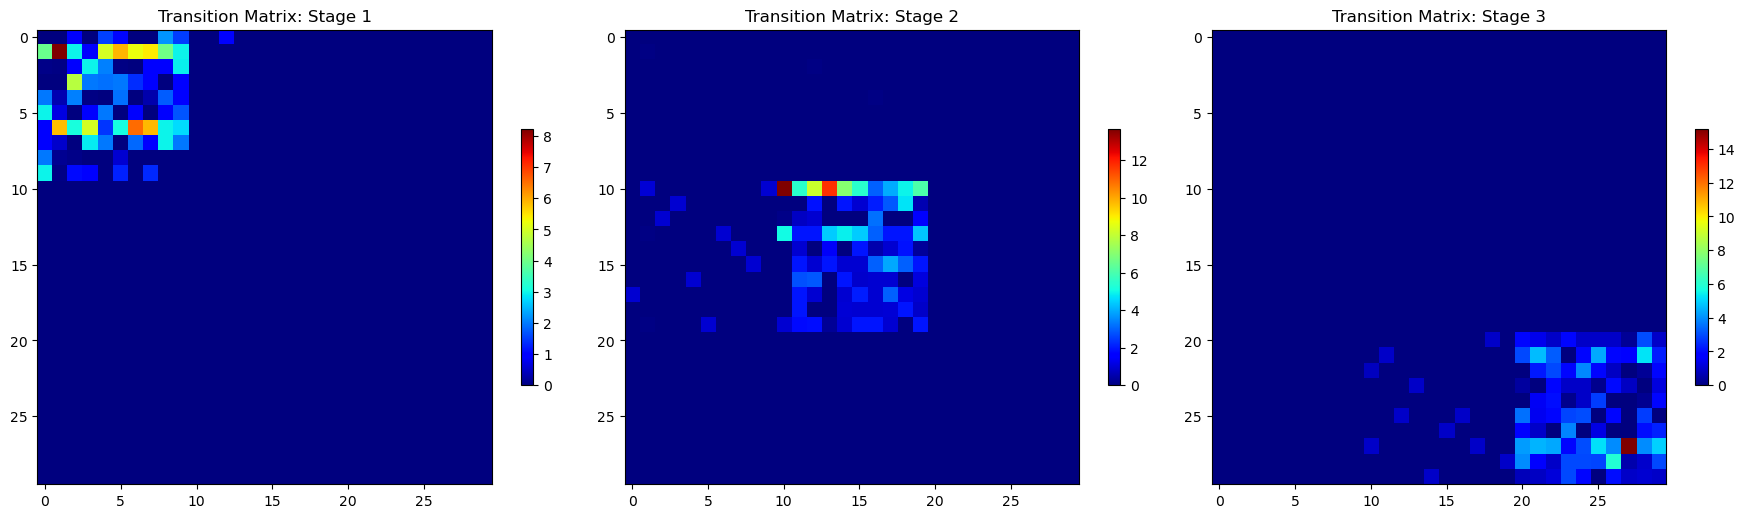

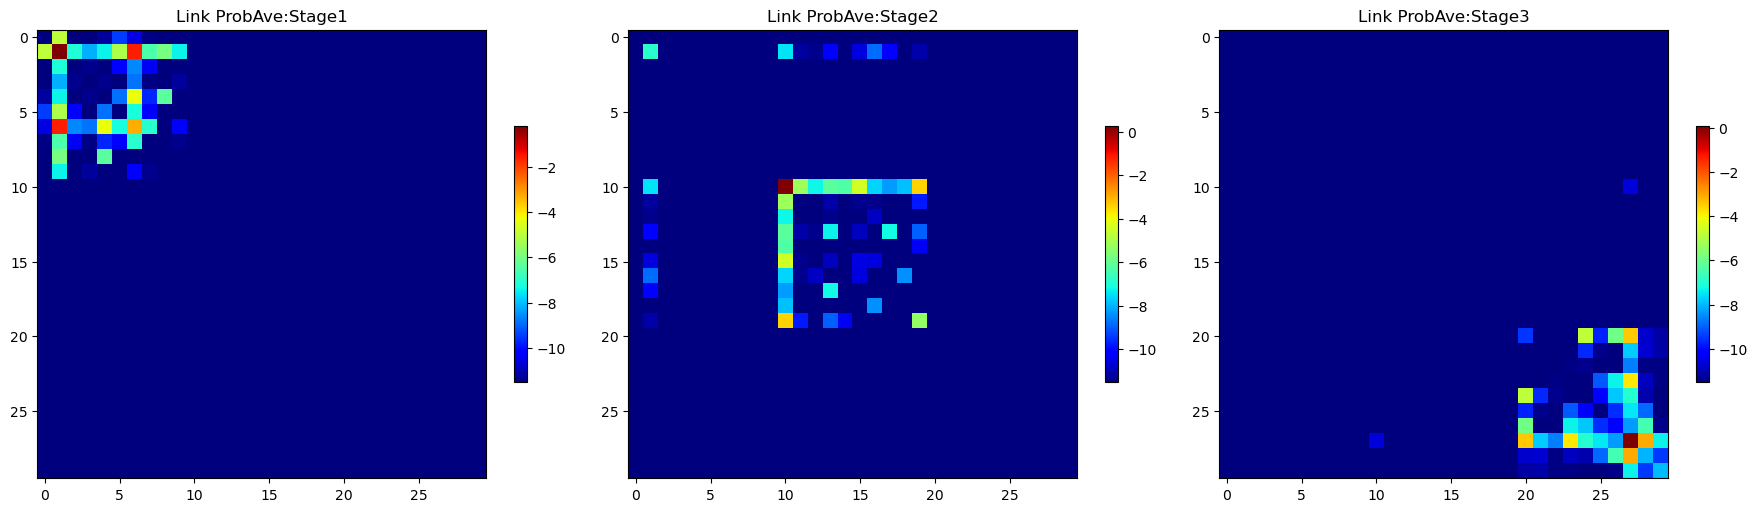

In [11]:
%matplotlib inline
#transition_steady = torch.stack(transition_steady) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(1, 3, figsize=(18,6))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        transition_sum = np.sum(np.array(transition_mean)[4:20], axis = 0)
    else:
        transition_sum = np.sum(np.array(transition_mean)[i*20: i*20+20], axis=0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Stage {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.45)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,3, figsize = (18,6))
for i in range(3):
    if i == 0:
        ProbAve = torch.mean(fs_prgds.ProbAve[4:20], axis = 0)
    else:
        ProbAve = torch.mean(fs_prgds.ProbAve[i*20:i*20+20], axis = 0) 
    im = axs[i].imshow(torch.log(ProbAve + ProbAve.T + 0.00001), cmap='jet')
    axs[i].set_title(f'Link ProbAve:Stage{i+1}')
    cbar = plt.colorbar(im, ax = axs[i], shrink=0.45)
plt.tight_layout()
plt.show()